In [ ]:
!nvidia-smi

Tue Sep 29 04:25:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             27W /   70W |     475MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics gradio opencv-python-headless matplotlib pandas pillow lxml

In [ ]:
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from xml.etree import ElementTree as ET

from ultralytics import YOLO

In [ ]:
%cd /content

!wget -q --show-progress \
"https://bigdatacup.s3.ap-northeast-1.amazonaws.com/2022/CRDDC2022/RDD2022/Country_Specific_Data_CRDDC2022/RDD2022_India.zip" \
-O RDD2022_India.zip

/content


In [ ]:
!ls -lh RDD2022_India.zip

-rw-r--r-- 1 root root 0 Sep 29 04:26 RDD2022_India.zip


In [ ]:
!mkdir -p /content/RDD2022_India
!unzip -q RDD2022_India.zip -d /content/RDD2022_India

[RDD2022_India.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of RDD2022_India.zip or
        RDD2022_India.zip.zip, and cannot find RDD2022_India.zip.ZIP, period.


In [ ]:
!rm -f /content/RDD2022_India.zip

In [ ]:
!ls -lh /content/RDD2022_India.zip

ls: cannot access '/content/RDD2022_India.zip': No such file or directory


In [ ]:
!pip install -q kaggle

In [ ]:
import os

print("Kaggle token exists:", "KAGGLE_API_TOKEN" in os.environ)

Kaggle token exists: False


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s "RDD2022 India" --max-size 10

No datasets found


In [ ]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.8 MB/s eta 0:00:00


In [ ]:
!kaggle --version

Kaggle CLI 2.2.4


In [ ]:
!kaggle datasets list -s "road damage"

ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
alvarobasily/road-damage                                         Road Damage                                          1755838057  2020-08-20 05:33:16.780000           3751         53  0.75             
lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes  Road Damage Dataset: Potholes, Cracks and Manholes    194168092  2026-02-10 15:26:14.110000           4702         37  0.875            
aliabdelmenam/rdd-2022                                           RDD 2022                                            10632799923  2025-02-23 02:30:31.640000          17857         74  0.6875  

In [ ]:
!kaggle datasets files aliabdelmenam/rdd-2022

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U5-NOpgh2ssOKWpN3zJwqMLNXZch9A1OcESpTdmpV0IFV6gqBqPs296CbX-Lu93UYxjAVptv4ZEGxKtjQJxQvh6lJtyZ13Z2jRS_baTLvdrwRx1zwRBNYY6AeWpbtsIwhHmCEbX-sbXV9WTW0le2_21pq8baw
name                                           size  creationDate                
--------------------------------------------  -----  --------------------------  
RDD_SPLIT/test/images/China_Drone_000008.jpg  78638  2025-02-23 02:32:56.797000  
RDD_SPLIT/test/images/China_Drone_000017.jpg  64331  2025-02-23 02:32:56.845000  
RDD_SPLIT/test/images/China_Drone_000040.jpg  47486  2025-02-23 02:32:56.840000  
RDD_SPLIT/test/images/China_Drone_000052.jpg  46816  2025-02-23 02:32:56.847000  
RDD_SPLIT/test/images/China_Drone_000053.jpg  83092  2025-02-23 02:32:56.847000  
RDD_SPLIT/test/images/China_Drone_000075.jpg  69208  2025-02-23 02:32:56.845000  
RDD_SPLIT/test/images/China_Drone_000085.jpg  57957  2025-02-23 02:32:56.845000  
RDD_SPLIT/test/images/China_Drone_000092.jpg  54474  2025-02-

In [ ]:
!kaggle datasets files sreekaraditya/rdd2022-yolo-crackscan-v2

Next Page Token = CfDJ8LXGgraiXMNClPzcySXY5U7NvIOr_AesNrpDA_wHYAGSMgJEH0aKuLKfOgVC-K3JmxH_ohdnPW0SzdmZqk0mxnx0D5vKxxk5jxnbU4HA4b_X6cF-316-3OzvEa_H1dJ3i4jBsvVGTWtD5WFu5HOTz71U2RIAylLuz9R0LzRA1w
name                                     size  creationDate                
--------------------------------------  -----  --------------------------  
data.yaml                                 279  2026-05-16 12:12:19.920000  
test/images/China_MotorBike_001977.jpg  90997  2026-05-16 12:13:36.451000  
test/images/China_MotorBike_001978.jpg  83739  2026-05-16 12:13:02.909000  
test/images/China_MotorBike_001979.jpg  88055  2026-05-16 12:13:06.144000  
test/images/China_MotorBike_001980.jpg  89432  2026-05-16 12:12:59.318000  
test/images/China_MotorBike_001981.jpg  58999  2026-05-16 12:12:55.725000  
test/images/China_MotorBike_001982.jpg  85489  2026-05-16 12:12:59.409000  
test/images/China_MotorBike_001983.jpg  55843  2026-05-16 12:13:02.565000  
test/images/China_MotorBike_001984.jpg  78128  

In [ ]:
!kaggle datasets files sreekaraditya/rdd2022-yolo-crackscan-v2 | grep -i "India" | head -50

In [ ]:
!kaggle datasets files sreekaraditya/rdd2022-yolo-crackscan-v2 | grep -i "India" | wc -l

0


In [ ]:
!kaggle datasets files aliabdelmenam/rdd-2022 | grep -i "India" | head -50


In [ ]:
!kaggle datasets files aliabdelmenam/rdd-2022 | grep -i "India" | wc -l

0


In [ ]:
!wget -O /content/RDD2022_India.zip \
"https://bigdatacup.s3.ap-northeast-1.amazonaws.com/2022/CRDDC2022/RDD2022/Country_Specific_Data_CRDDC2022/RDD2022_India.zip"

!ls -lh /content/RDD2022_India.zip

--2026-09-29 04:41:27--  https://bigdatacup.s3.ap-northeast-1.amazonaws.com/2022/CRDDC2022/RDD2022/Country_Specific_Data_CRDDC2022/RDD2022_India.zip
Resolving bigdatacup.s3.ap-northeast-1.amazonaws.com (bigdatacup.s3.ap-northeast-1.amazonaws.com)... 52.219.150.122, 3.5.157.176, 52.219.199.14, ...
Connecting to bigdatacup.s3.ap-northeast-1.amazonaws.com (bigdatacup.s3.ap-northeast-1.amazonaws.com)|52.219.150.122|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-09-29 04:41:28 ERROR 403: Forbidden.

-rw-r--r-- 1 root root 0 Sep 29 04:41 /content/RDD2022_India.zip


In [ ]:
!pip install -q roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="7BsNd3ey2MFAx3cXdB5S")
project = rf.workspace("prakhar-kpb1v").project("rdd2022-india-il8ju")
version = project.version(5)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to RDD2022-India-5 in yolov11:: 100%|██████████| 15424/15424 [00:02<00:00, 5355.03it/s]


In [ ]:
import os

print("Dataset location:")
print(dataset.location)

print("\nFiles:")
!find "$dataset.location" -maxdepth 2 -type f | head -30

Dataset location:
/content/RDD2022-India-5

Files:
/content/RDD2022-India-5/README.roboflow.txt
/content/RDD2022-India-5/README.dataset.txt
/content/RDD2022-India-5/data.yaml


In [ ]:
import os

base = "/content/RDD2022-India-5"

for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

    for file in files[:5]:
        print(f"{indent}  {file}")

RDD2022-India-5/
  README.roboflow.txt
  README.dataset.txt
  data.yaml
  test/
    labels/
      India_002947_jpg.rf.98bc6326cb36c45f9747bbb2a1386538.txt
      India_005375_jpg.rf.a2fd1b0717bbf0375b6852e5b8987d2d.txt
      India_005107_jpg.rf.5cd66e43e9d3bb21e00d932759b29fd1.txt
      India_008708_jpg.rf.a1bf516789d6ab9582f2a22df6c349d2.txt
      India_004914_jpg.rf.005798b67f1e159a7df8e99ca269b6b6.txt
    images/
      India_006079_jpg.rf.1c7318d5ea1c319b77b265ccd448c084.jpg
      India_008471_jpg.rf.5f95c0427addd6dad28828c19aefd0ba.jpg
      India_004868_jpg.rf.de6a7ad58fc9d08a07dc42df48e4e789.jpg
      India_005871_jpg.rf.5b7ec54ee361d9382487ebcf290f8d99.jpg
      India_004551_jpg.rf.4d2078fce17a41ae2ada5d8030440514.jpg
  valid/
    labels/
      India_009122_jpg.rf.66ff976b8e52824ebd130635212d68c8.txt
      India_007016_jpg.rf.a631bfd0c3db2be0e26d277511da44d1.txt
      India_003936_jpg.rf.77a7c4ce13f7c2ffdb37b192a052fe86.txt
      India_003444_jpg.rf.e4d40c866f02c045669d507897faa5

In [ ]:
import yaml

yaml_path = "/content/RDD2022-India-5/data.yaml"

with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 10, 'names': ['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50'], 'roboflow': {'workspace': 'prakhar-kpb1v', 'project': 'rdd2022-india-il8ju', 'version': 5, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/prakhar-kpb1v/rdd2022-india-il8ju/dataset/5'}}


In [ ]:
print(open("/content/RDD2022-India-5/README.dataset.txt").read())

# RDD2022-India > RDD2022-India
https://universe.roboflow.com/prakhar-kpb1v/rdd2022-india-il8ju

Provided by a Roboflow user
License: CC BY 4.0




In [ ]:
import os
import glob

for file in glob.glob("/content/RDD2022-India-5/**/*", recursive=True):
    if os.path.isfile(file) and ("README" in os.path.basename(file).upper() or file.endswith(".yaml")):
        print("\n" + "="*80)
        print(file)
        print("="*80)
        try:
            print(open(file, encoding="utf-8").read()[:10000])
        except:
            pass


/content/RDD2022-India-5/README.roboflow.txt

RDD2022-India - v5 RDD2022-India

This dataset was exported via roboflow.com on August 29, 2025 at 6:51 AM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 7706 images.
Decays are annotated in YOLOv11 format.

The following pre-processing was applied to each image:

No image augmentation techniques were applied.




/content/RDD2022-India-5/README.dataset.txt
# RDD2022-India > RDD2022-India
https://universe.

In [ ]:
print(open("/content/RDD2022-India-5/README.roboflow.txt").read())


RDD2022-India - v5 RDD2022-India

This dataset was exported via roboflow.com on August 29, 2025 at 6:51 AM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 7706 images.
Decays are annotated in YOLOv11 format.

The following pre-processing was applied to each image:

No image augmentation techniques were applied.





In [ ]:
from pathlib import Path
from collections import Counter

label_dir = Path("/content/RDD2022-India-5")

class_counts = Counter()

for split in ["train", "valid", "test"]:
    for txt_file in (label_dir / split / "labels").glob("*.txt"):
        with open(txt_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counts[int(parts[0])] += 1

names = data_config["names"]

print("Class distribution:")
for class_id, count in sorted(class_counts.items()):
    print(f"{class_id}: {names[class_id]:5s} -> {count:,}")

Class distribution:
0: D00   -> 1,555
1: D01   -> 179
2: D0w0  -> 1
3: D10   -> 68
4: D11   -> 45
5: D20   -> 2,021
6: D40   -> 3,187
7: D43   -> 57
8: D44   -> 1,062
9: D50   -> 28


In [ ]:
from pathlib import Path
from collections import Counter

base = Path("/content/RDD2022-India-5")

for split in ["train", "valid", "test"]:
    image_dir = base / split / "images"
    label_dir = base / split / "labels"

    image_count = len(list(image_dir.glob("*")))
    class_images = Counter()

    for label_file in label_dir.glob("*.txt"):
        classes_in_image = set()

        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes_in_image.add(int(parts[0]))

        for c in classes_in_image:
            class_images[c] += 1

    print(f"\n{split.upper()}")
    print("Images:", image_count)

    for c in [0, 3, 5, 6]:
        print(f"{data_config['names'][c]}: {class_images[c]} images")


TRAIN
Images: 6532
D00: 946 images
D10: 51 images
D20: 1486 images
D40: 1296 images

VALID
Images: 786
D00: 115 images
D10: 4 images
D20: 186 images
D40: 159 images

TEST
Images: 388
D00: 48 images
D10: 5 images
D20: 86 images
D40: 75 images


In [ ]:
from pathlib import Path
import shutil
import yaml

# Source and destination
SOURCE = Path("/content/RDD2022-India-5")
DEST = Path("/content/RDD2022_India_4class")

# Original class IDs → new class IDs
CLASS_MAPPING = {
    0: 0,  # D00 → Longitudinal Crack
    3: 1,  # D10 → Transverse Crack
    5: 2,  # D20 → Alligator Crack
    6: 3   # D40 → Pothole
}

CLASS_NAMES = [
    "Longitudinal Crack",
    "Transverse Crack",
    "Alligator Crack",
    "Pothole"
]

# Create destination directories
for split in ["train", "valid", "test"]:
    (DEST / split / "images").mkdir(parents=True, exist_ok=True)
    (DEST / split / "labels").mkdir(parents=True, exist_ok=True)

# Process every split
summary = {}

for split in ["train", "valid", "test"]:
    source_images = SOURCE / split / "images"
    source_labels = SOURCE / split / "labels"

    kept_images = 0
    kept_annotations = 0

    for label_file in source_labels.glob("*.txt"):

        new_annotations = []

        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                old_class = int(parts[0])

                # Keep only our four target classes
                if old_class in CLASS_MAPPING:
                    new_class = CLASS_MAPPING[old_class]

                    new_annotations.append(
                        f"{new_class} {' '.join(parts[1:])}"
                    )

        # Skip images containing none of our four classes
        if not new_annotations:
            continue

        # Find corresponding image
        image_candidates = list(
            source_images.glob(label_file.stem + ".*")
        )

        if not image_candidates:
            continue

        source_image = image_candidates[0]

        # Copy image
        destination_image = DEST / split / "images" / source_image.name
        shutil.copy2(source_image, destination_image)

        # Write cleaned labels
        destination_label = DEST / split / "labels" / label_file.name

        with open(destination_label, "w") as f:
            f.write("\n".join(new_annotations) + "\n")

        kept_images += 1
        kept_annotations += len(new_annotations)

    summary[split] = {
        "images": kept_images,
        "annotations": kept_annotations
    }

# Create data.yaml
data_yaml = {
    "path": str(DEST),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 4,
    "names": CLASS_NAMES
}

with open(DEST / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("4-class dataset created successfully!\n")

for split, stats in summary.items():
    print(
        f"{split.upper():6s} → "
        f"{stats['images']:,} images | "
        f"{stats['annotations']:,} annotations"
    )

print("\nDataset:", DEST)
print("YAML:", DEST / "data.yaml")

4-class dataset created successfully!

TRAIN  → 2,738 images | 5,760 annotations
VALID  → 338 images | 732 annotations
TEST   → 147 images | 339 annotations

Dataset: /content/RDD2022_India_4class
YAML: /content/RDD2022_India_4class/data.yaml


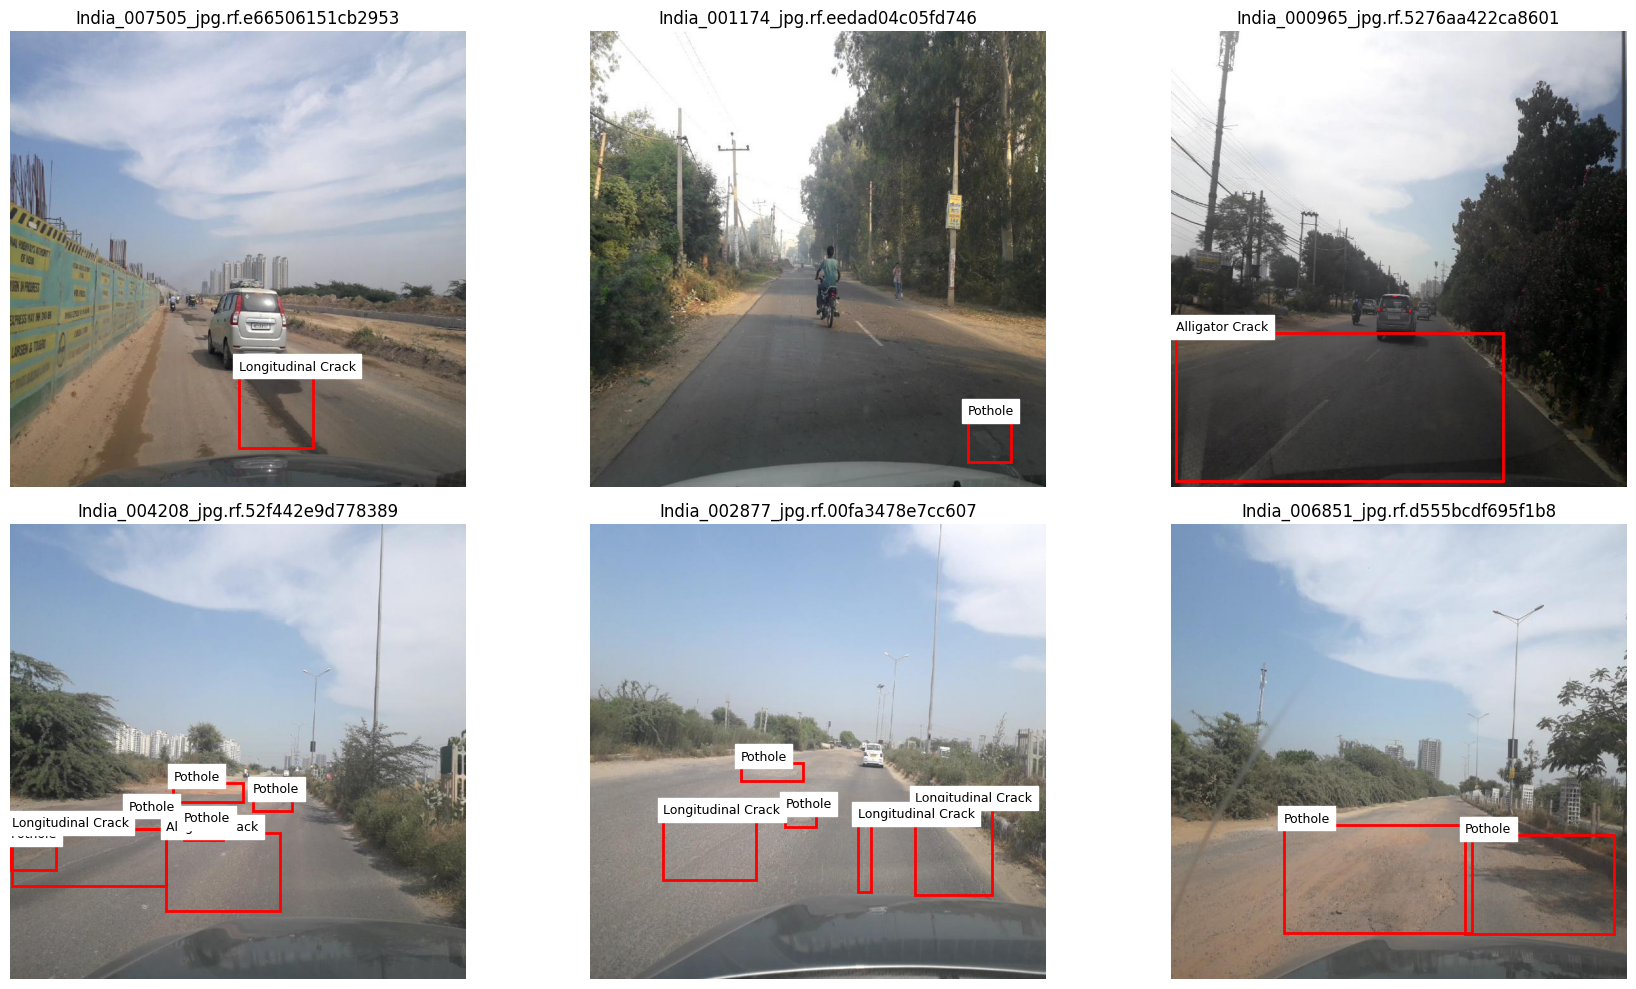

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
import random

base = Path("/content/RDD2022_India_4class")

class_names = [
    "Longitudinal Crack",
    "Transverse Crack",
    "Alligator Crack",
    "Pothole"
]

# Select 6 random training images
image_files = list((base / "train" / "images").glob("*.jpg"))
sample_images = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):

    image = Image.open(image_path)
    width, height = image.size

    ax.imshow(image)

    label_path = base / "train" / "labels" / f"{image_path.stem}.txt"

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                class_id = int(parts[0])
                x_center, y_center, box_width, box_height = map(
                    float, parts[1:]
                )

                # YOLO normalized coordinates → pixels
                x_center *= width
                y_center *= height
                box_width *= width
                box_height *= height

                x = x_center - box_width / 2
                y = y_center - box_height / 2

                rect = patches.Rectangle(
                    (x, y),
                    box_width,
                    box_height,
                    linewidth=2,
                    edgecolor="red",
                    facecolor="none"
                )

                ax.add_patch(rect)

                ax.text(
                    x,
                    max(0, y - 5),
                    class_names[class_id],
                    fontsize=9,
                    backgroundcolor="white"
                )

    ax.set_title(image_path.name[:35])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

base = Path("/content/RDD2022_India_4class")

class_names = [
    "Longitudinal Crack",
    "Transverse Crack",
    "Alligator Crack",
    "Pothole"
]

# Find images containing ONLY pothole annotations
pothole_only = []

for label_file in (base / "train" / "labels").glob("*.txt"):
    classes = []

    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                classes.append(int(parts[0]))

    if classes and all(c == 3 for c in classes):
        image_path = base / "train" / "images" / (label_file.stem + ".jpg")

        if image_path.exists():
            pothole_only.append(image_path)

print("Pothole-only images:", len(pothole_only))

Pothole-only images: 660


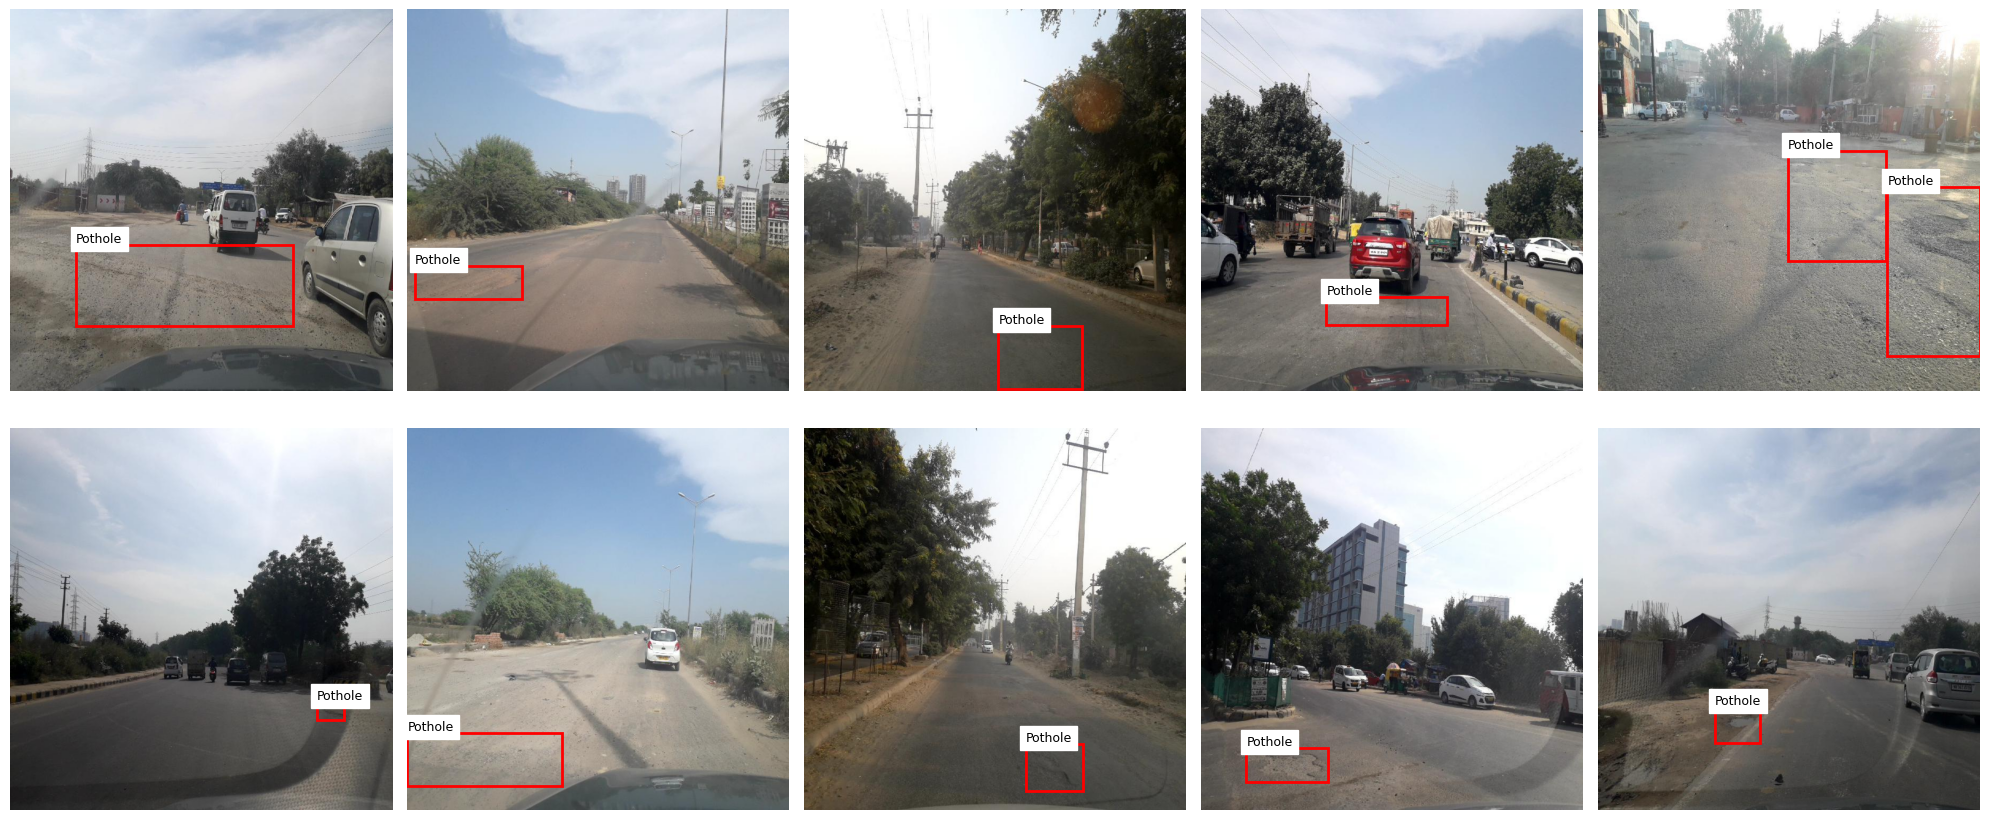

In [ ]:
samples = random.sample(
    pothole_only,
    min(10, len(pothole_only))
)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for ax, image_path in zip(axes, samples):

    image = Image.open(image_path)
    width, height = image.size

    ax.imshow(image)

    label_path = base / "train" / "labels" / f"{image_path.stem}.txt"

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])

            xc *= width
            yc *= height
            w *= width
            h *= height

            x = xc - w / 2
            y = yc - h / 2

            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)
            ax.text(
                x, max(0, y - 5),
                class_names[class_id],
                fontsize=9,
                backgroundcolor="white"
            )

    ax.axis("off")

plt.tight_layout()
plt.show()

New

In [ ]:
import requests

article_id = 21431547

url = f"https://api.figshare.com/v2/articles/{article_id}/files"

response = requests.get(url)
response.raise_for_status()

files = response.json()

for f in files:
    print(f["id"], "|", f["name"], "|", f["size"])


38030910 | RDD2022_released_through_CRDDC2022.zip | 13264172619
38030823 | Directory_Structure_CRDDC_RDD2022.txt | 1161
38030826 | File_List_CRDDC_RDD2022.txt | 3250534
38030820 | label_map.pbtxt | 127


In [ ]:
import requests

file_id = 38030826

url = f"https://api.figshare.com/v2/file/download/{file_id}"

response = requests.get(url)
response.raise_for_status()

with open("/content/File_List_CRDDC_RDD2022.txt", "wb") as f:
    f.write(response.content)

print("Downloaded:", len(response.content), "bytes")

Downloaded: 3250534 bytes


In [ ]:
!grep -i "India" /content/File_List_CRDDC_RDD2022.txt | head -30


+---India
|   |           India_000004.jpg
|   |           India_000006.jpg
|   |           India_000008.jpg
|   |           India_000009.jpg
|   |           India_000013.jpg
|   |           India_000015.jpg
|   |           India_000020.jpg
|   |           India_000021.jpg
|   |           India_000025.jpg
|   |           India_000029.jpg
|   |           India_000030.jpg
|   |           India_000031.jpg
|   |           India_000033.jpg
|   |           India_000034.jpg
|   |           India_000045.jpg
|   |           India_000048.jpg
|   |           India_000050.jpg
|   |           India_000051.jpg
|   |           India_000056.jpg
|   |           India_000058.jpg
|   |           India_000060.jpg
|   |           India_000062.jpg
|   |           India_000063.jpg
|   |           India_000065.jpg
|   |           India_000068.jpg
|   |           India_000070.jpg
|   |           India_000077.jpg
|   |           India_000082.jpg
|   |           India_000084.jpg


In [ ]:
!grep -i "India.*xml" /content/File_List_CRDDC_RDD2022.txt | head -20

|       |           India_000000.xml
|       |           India_000001.xml
|       |           India_000002.xml
|       |           India_000003.xml
|       |           India_000005.xml
|       |           India_000007.xml
|       |           India_000010.xml
|       |           India_000011.xml
|       |           India_000012.xml
|       |           India_000014.xml
|       |           India_000016.xml
|       |           India_000017.xml
|       |           India_000018.xml
|       |           India_000019.xml
|       |           India_000022.xml
|       |           India_000023.xml
|       |           India_000024.xml
|       |           India_000026.xml
|       |           India_000027.xml
|       |           India_000028.xml


In [ ]:
!grep -i "India.*annotations" /content/File_List_CRDDC_RDD2022.txt | head -20

In [ ]:
import requests

file_id = 38030823
url = f"https://api.figshare.com/v2/file/download/{file_id}"

response = requests.get(url)
response.raise_for_status()

with open("/content/Directory_Structure_CRDDC_RDD2022.txt", "wb") as f:
    f.write(response.content)

print("Downloaded successfully")
print("Size:", len(response.content), "bytes")

Downloaded successfully
Size: 1161 bytes


In [ ]:
print("---- India-related entries ----")
!grep -n -i "India" /content/Directory_Structure_CRDDC_RDD2022.txt

---- India-related entries ----
24:    +---India


In [ ]:
print("---- XML-related entries ----")
!grep -n -i "xml" /content/Directory_Structure_CRDDC_RDD2022.txt

---- XML-related entries ----
8:    |       |   \---xmls
15:    |       |   \---xmls
22:    |       |   \---xmls
29:    |       |   \---xmls
36:    |       |   \---xmls
43:    |       |   \---xmls
50:            |   \---xmls


In [ ]:
with open("/content/Directory_Structure_CRDDC_RDD2022.txt", "r") as f:
    print(f.read())

Folder PATH listing for volume Windows
Volume serial number is 520B-286B
C:.
\---RDD2022
    +---China_Drone
    |   \---train
    |       +---annotations
    |       |   \---xmls
    |       \---images
    +---China_MotorBike
    |   +---test
    |   |   \---images
    |   \---train
    |       +---annotations
    |       |   \---xmls
    |       \---images
    +---Czech
    |   +---test
    |   |   \---images
    |   \---train
    |       +---annotations
    |       |   \---xmls
    |       \---images
    +---India
    |   +---test
    |   |   \---images
    |   \---train
    |       +---annotations
    |       |   \---xmls
    |       \---images
    +---Japan
    |   +---test
    |   |   \---images
    |   \---train
    |       +---annotations
    |       |   \---xmls
    |       \---images
    +---Norway
    |   +---test
    |   |   \---images
    |   \---train
    |       +---annotations
    |       |   \---xmls
    |       \---images
    \---United_States
        +---test
       

In [ ]:
import requests

zip_url = "https://figshare.com/ndownloader/files/38030910"

r = requests.head(zip_url, allow_redirects=True)

print("Status:", r.status_code)
print("Final URL:", r.url)
print("Content-Length:", r.headers.get("Content-Length"))
print("Accept-Ranges:", r.headers.get("Accept-Ranges"))

Status: 202
Final URL: https://figshare.com/ndownloader/files/38030910
Content-Length: 0
Accept-Ranges: None


In [ ]:
!pip install -q roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="7BsNd3ey2MFAx3cXdB5S")

project = rf.workspace("prakhar-kpb1v").project("rdd2022-india-il8ju")
version = project.version(5)

dataset = version.download("voc")

print("Downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Downloaded to: /content/RDD2022-India-5


In [ ]:
import os

print(dataset.location)

for root, dirs, files in os.walk(dataset.location):
    level = root.replace(dataset.location, "").count(os.sep)
    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

/content/RDD2022-India-5
RDD2022-India-5/
  test/
  valid/
  train/


In [ ]:
import glob

xml_files = glob.glob(
    os.path.join(dataset.location, "**", "*.xml"),
    recursive=True
)

print("XML files:", len(xml_files))
print("First 5:")
for x in xml_files[:5]:
    print(x)

XML files: 7706
First 5:
/content/RDD2022-India-5/test/India_002803_jpg.rf.10c82592694bac11c3dccd67cdf75527.xml
/content/RDD2022-India-5/test/India_007504_jpg.rf.1139962c23cebcbdebe85c55f96a448d.xml
/content/RDD2022-India-5/test/India_003528_jpg.rf.0445126f47d639bf8c3129b9fc27cbc7.xml
/content/RDD2022-India-5/test/India_006223_jpg.rf.d343c4e718e4e98a079a454d01a9fd42.xml
/content/RDD2022-India-5/test/India_002647_jpg.rf.b635c9bf09a4fc6205866ae99a91a3d9.xml


In [ ]:
import xml.etree.ElementTree as ET
from collections import Counter

classes = Counter()

for xml_file in xml_files:
    root = ET.parse(xml_file).getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        classes[name] += 1

print("Class distribution:")
for name, count in classes.most_common():
    print(f"{name}: {count}")

Class distribution:
D40: 3187
D20: 2021
D00: 1555
D44: 1062
D01: 179
D10: 68
D43: 57
D11: 45
D50: 28
D0w0: 1


In [ ]:
import os
import glob
import shutil
import xml.etree.ElementTree as ET
from collections import Counter

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

SOURCE = dataset.location
OUTPUT = "/content/RDD2022_India_4class"

CLASS_MAPPING = {
    "D00": 0,   # Longitudinal Crack
    "D10": 1,   # Transverse Crack
    "D20": 2,   # Alligator Crack
    "D40": 3    # Pothole
}

CLASS_NAMES = [
    "Longitudinal Crack",
    "Transverse Crack",
    "Alligator Crack",
    "Pothole"
]

# --------------------------------------------------
# FIND IMAGES AND XML FILES
# --------------------------------------------------

image_files = glob.glob(
    os.path.join(SOURCE, "**", "*.jpg"),
    recursive=True
)

xml_files = glob.glob(
    os.path.join(SOURCE, "**", "*.xml"),
    recursive=True
)

print("Images found:", len(image_files))
print("XML files found:", len(xml_files))

# Map image filename -> path
image_map = {
    os.path.basename(x): x
    for x in image_files
}

# --------------------------------------------------
# CREATE OUTPUT FOLDERS
# --------------------------------------------------

for split in ["train", "valid", "test"]:
    os.makedirs(f"{OUTPUT}/{split}/images", exist_ok=True)
    os.makedirs(f"{OUTPUT}/{split}/labels", exist_ok=True)

# --------------------------------------------------
# DETERMINE SPLIT FROM SOURCE PATH
# --------------------------------------------------

def get_split(path):
    path_lower = path.lower()

    if "/train/" in path_lower:
        return "train"
    elif "/valid/" in path_lower or "/val/" in path_lower:
        return "valid"
    elif "/test/" in path_lower:
        return "test"

    return None

# --------------------------------------------------
# CONVERT XML → YOLO
# --------------------------------------------------

annotation_counts = Counter()
image_counts = Counter()

for xml_file in xml_files:

    split = get_split(xml_file)

    if split is None:
        continue

    root = ET.parse(xml_file).getroot()

    filename_node = root.find("filename")

    if filename_node is None:
        continue

    filename = filename_node.text.strip()

    if filename not in image_map:
        continue

    image_path = image_map[filename]

    size = root.find("size")

    if size is None:
        continue

    width = int(size.find("width").text)
    height = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        class_node = obj.find("name")

        if class_node is None:
            continue

        class_name = class_node.text.strip()

        # Ignore unwanted RDD classes
        if class_name not in CLASS_MAPPING:
            continue

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Clamp coordinates
        xmin = max(0, min(xmin, width))
        xmax = max(0, min(xmax, width))
        ymin = max(0, min(ymin, height))
        ymax = max(0, min(ymax, height))

        # Skip invalid boxes
        if xmax <= xmin or ymax <= ymin:
            continue

        # YOLO format
        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height
        box_width = (xmax - xmin) / width
        box_height = (ymax - ymin) / height

        class_id = CLASS_MAPPING[class_name]

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} "
            f"{box_width:.6f} {box_height:.6f}"
        )

        annotation_counts[class_name] += 1

    # Only keep images containing one of our 4 target classes
    if not yolo_lines:
        continue

    # Copy image
    destination_image = (
        f"{OUTPUT}/{split}/images/{filename}"
    )

    shutil.copy2(image_path, destination_image)

    # Write YOLO label
    label_filename = os.path.splitext(filename)[0] + ".txt"

    destination_label = (
        f"{OUTPUT}/{split}/labels/{label_filename}"
    )

    with open(destination_label, "w") as f:
        f.write("\n".join(yolo_lines))

    image_counts[split] += 1

# --------------------------------------------------
# RESULTS
# --------------------------------------------------

print("\nDataset created!")
print("-----------------------------")

for split in ["train", "valid", "test"]:
    img_count = len(
        glob.glob(f"{OUTPUT}/{split}/images/*")
    )
    label_count = len(
        glob.glob(f"{OUTPUT}/{split}/labels/*.txt")
    )

    print(
        f"{split.upper():6} | "
        f"Images: {img_count:5} | "
        f"Labels: {label_count:5}"
    )

print("\nTarget annotation counts:")

for cls in CLASS_NAMES:
    original_name = {
        "Longitudinal Crack": "D00",
        "Transverse Crack": "D10",
        "Alligator Crack": "D20",
        "Pothole": "D40"
    }[cls]

    print(
        f"{cls:20} : "
        f"{annotation_counts[original_name]}"
    )

Images found: 7706
XML files found: 7706

Dataset created!
-----------------------------
TRAIN  | Images:  2738 | Labels:  2738
VALID  | Images:   338 | Labels:   338
TEST   | Images:   147 | Labels:   147

Target annotation counts:
Longitudinal Crack   : 1555
Transverse Crack     : 68
Alligator Crack      : 2021
Pothole              : 3187


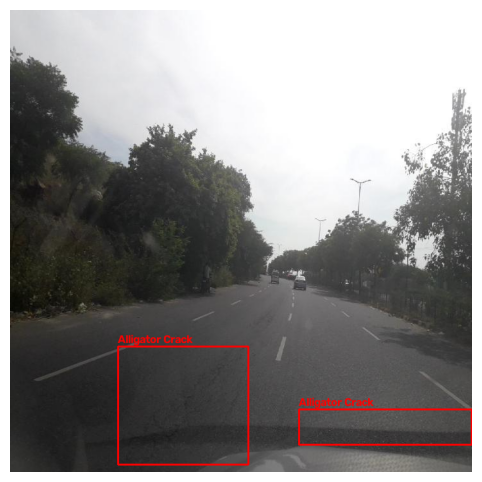

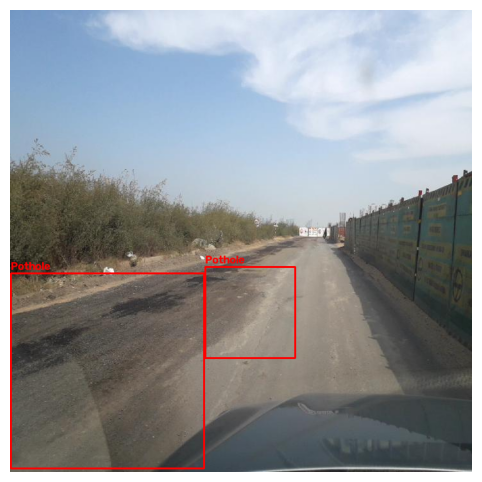

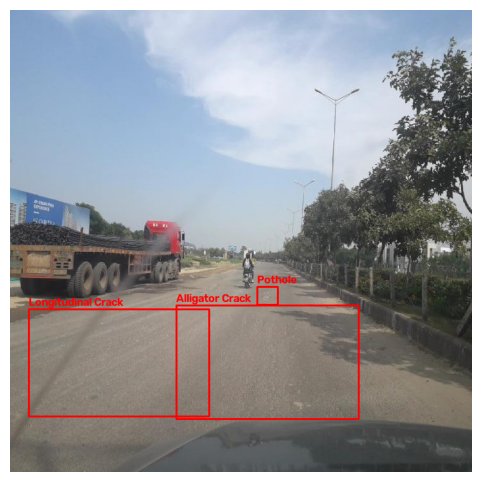

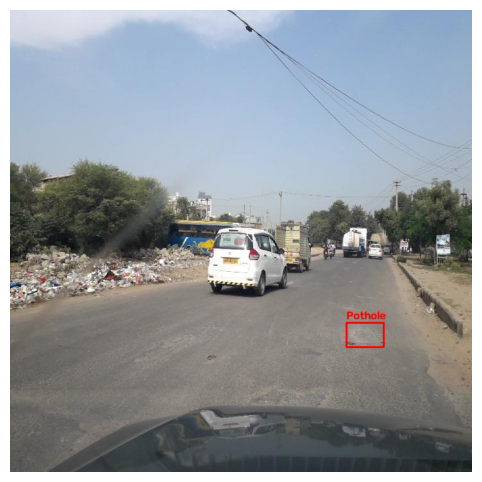

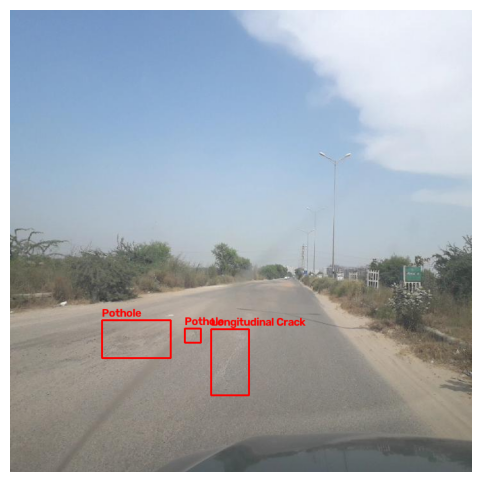

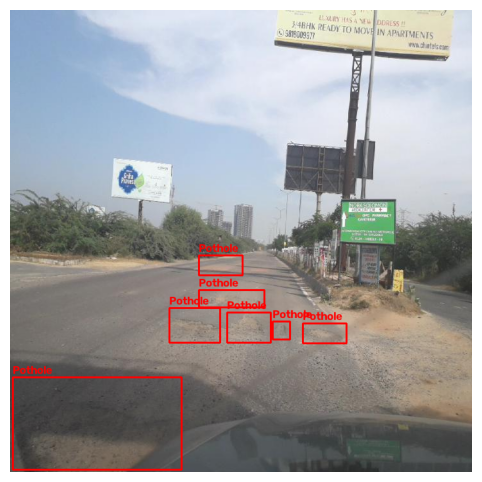

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

CLASS_NAMES = [
    "Longitudinal Crack",
    "Transverse Crack",
    "Alligator Crack",
    "Pothole"
]

image_files = glob.glob(
    "/content/RDD2022_India_4class/train/images/*.jpg"
)

sample_images = random.sample(
    image_files,
    min(6, len(image_files))
)

for image_path in sample_images:

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_path = image_path.replace(
        "/images/",
        "/labels/"
    ).replace(".jpg", ".txt")

    if os.path.exists(label_path):

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            class_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])

            xmin = int((xc - bw / 2) * w)
            ymin = int((yc - bh / 2) * h)
            xmax = int((xc + bw / 2) * w)
            ymax = int((yc + bh / 2) * h)

            cv2.rectangle(
                image,
                (xmin, ymin),
                (xmax, ymax),
                (255, 0, 0),
                2
            )

            cv2.putText(
                image,
                CLASS_NAMES[class_id],
                (xmin, max(20, ymin - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [ ]:
import yaml

data = {
    "path": "/content/RDD2022_India_4class",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 4,
    "names": [
        "Longitudinal Crack",
        "Transverse Crack",
        "Alligator Crack",
        "Pothole"
    ]
}

with open("/content/RDD2022_India_4class/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(open("/content/RDD2022_India_4class/data.yaml").read())

path: /content/RDD2022_India_4class
train: train/images
val: valid/images
test: test/images
nc: 4
names:
- Longitudinal Crack
- Transverse Crack
- Alligator Crack
- Pothole



In [ ]:
!pip install -q ultralytics

In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not detected")

GPU available: True
GPU: Tesla T4


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/RDD2022_India_4class/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project="/content/Road_Damage_Project",
    name="YOLO11n_India",
    pretrained=True,
    device=0,
    seed=42
)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022_India_4class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n_India-2, nbs=64, nms=None, opset=None, op

KeyboardInterrupt: 

In [ ]:
import os

best_model_path = (
    "/content/Road_Damage_Project/"
    "YOLO11n_India/weights/best.pt"
)

print("Best model exists:", os.path.exists(best_model_path))
print(best_model_path)

Best model exists: True
/content/Road_Damage_Project/YOLO11n_India/weights/best.pt


In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/Road_Damage_Project/"
    "YOLO11n_India/weights/best.pt"
)

metrics = best_model.val(
    data="/content/RDD2022_India_4class/data.yaml",
    split="test",
    imgsz=640,
    device=0
)

print("\nOverall Metrics")
print("-----------------------")
print("Precision :", round(metrics.box.mp, 4))
print("Recall    :", round(metrics.box.mr, 4))
print("mAP@50   :", round(metrics.box.map50, 4))
print("mAP@50-95:", round(metrics.box.map, 4))

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1943.4±205.0 MB/s, size: 60.9 KB)
val: Scanning /content/RDD2022_India_4class/test/labels.cache... 147 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 147/147 47.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.8it/s 3.5s
                   all        147        339      0.453      0.342      0.383      0.158
    Longitudinal Crack         48         67      0.589      0.373      0.436      0.182
      Transverse Crack          5          5          0          0     0.0177    0.00203
       Alligator Crack         86        100      0.698      0.601      0.654      0.301
               Pothole         75        167      0.524      0.395      0.427      0.146
Speed: 4.0ms preprocess, 5.6ms in

Testing: /content/RDD2022_India_4class/test/images/India_008471_jpg.rf.5f95c0427addd6dad28828c19aefd0ba.jpg

image 1/1 /content/RDD2022_India_4class/test/images/India_008471_jpg.rf.5f95c0427addd6dad28828c19aefd0ba.jpg: 640x640 1 Alligator Crack, 7.7ms
Speed: 2.1ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
Prediction saved to: /content/runs/detect/predict-2


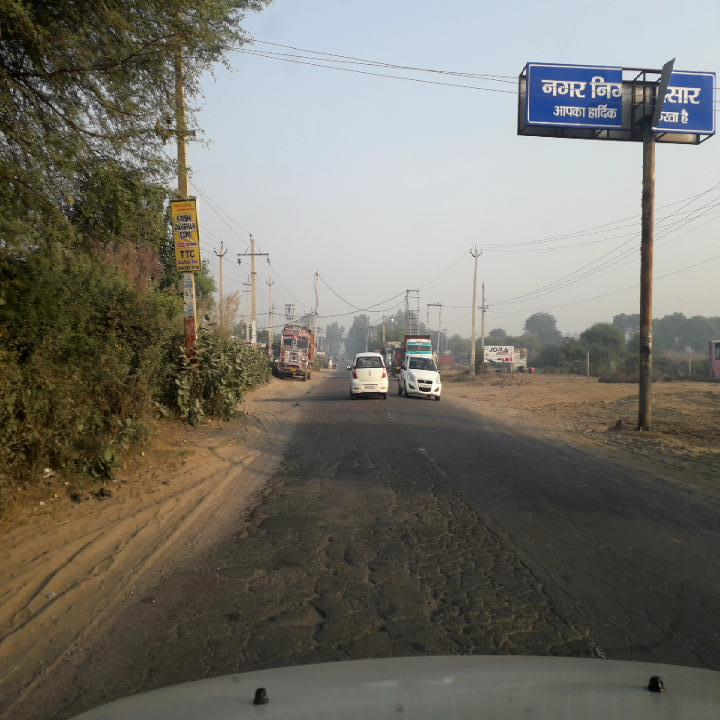

array([[[ 17,  46,  53],
        [ 24,  53,  60],
        [ 42,  71,  78],
        ...,
        [224, 215, 205],
        [224, 215, 205],
        [224, 215, 205]],

       [[ 15,  44,  51],
        [ 16,  45,  52],
        [ 28,  57,  64],
        ...,
        [224, 215, 205],
        [224, 215, 205],
        [224, 215, 205]],

       [[  8,  40,  46],
        [  8,  40,  46],
        [ 16,  48,  54],
        ...,
        [224, 215, 205],
        [224, 215, 205],
        [224, 215, 205]],

       ...,

       [[ 47,  65,  76],
        [ 51,  69,  80],
        [ 52,  70,  81],
        ...,
        [ 86,  94,  93],
        [ 86,  94,  93],
        [ 86,  94,  93]],

       [[ 40,  60,  71],
        [ 42,  62,  73],
        [ 44,  62,  73],
        ...,
        [ 86,  94,  93],
        [ 86,  94,  93],
        [ 86,  94,  93]],

       [[ 37,  57,  68],
        [ 38,  58,  69],
        [ 40,  58,  69],
        ...,
        [ 86,  94,  93],
        [ 86,  94,  93],
        [ 86,  94,  93]]], dtype=uint8)
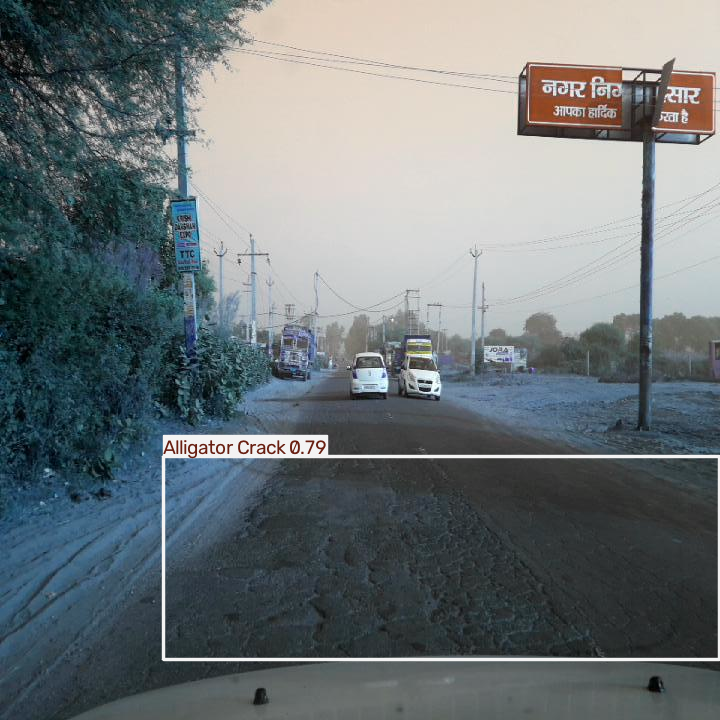

In [ ]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
import glob
import os

best_model = YOLO(
    "/content/Road_Damage_Project/YOLO11n_India/weights/best.pt"
)

# Pick one test image
test_images = glob.glob(
    "/content/RDD2022_India_4class/test/images/*.jpg"
)

test_image = test_images[0]

print("Testing:", test_image)

results = best_model.predict(
    source=test_image,
    conf=0.25,
    imgsz=640,
    save=True
)

# Display annotated result
annotated_path = results[0].save_dir

print("Prediction saved to:", annotated_path)

display(Image.open(test_image))
display(results[0].plot())

In [ ]:
TYPE_WEIGHT = {
    "Longitudinal Crack": 0.50,
    "Transverse Crack": 0.55,
    "Alligator Crack": 0.80,
    "Pothole": 1.00
}


def calculate_severity(
    class_name,
    box_area_ratio,
    total_defects
):
    # Larger damaged area → higher severity
    size_score = min(box_area_ratio / 10.0, 1.0)

    # More detected defects → higher severity
    count_score = min(total_defects / 5.0, 1.0)

    # Different defect types have different structural implications
    type_score = TYPE_WEIGHT.get(class_name, 0.5)

    score = (
        0.60 * size_score +
        0.20 * count_score +
        0.20 * type_score
    ) * 100

    if score < 35:
        severity = "Low"
    elif score < 65:
        severity = "Medium"
    else:
        severity = "High"

    return severity, round(score, 1)


print(calculate_severity("Pothole", 5.0, 2))

('Medium', 58.0)


In [ ]:
# ============================================================
# ROADVISION AI - FINAL MBA-FRIENDLY DASHBOARD
# Detect → Assess → Prioritize → Explain
# ============================================================

import gradio as gr
import pandas as pd
import numpy as np
from PIL import Image

# ------------------------------------------------------------
# 1. DASHBOARD ANALYSIS
# ------------------------------------------------------------

def dashboard_analysis(image, confidence=0.15):

    annotated, summary = analyze_road(
        image=image,
        confidence=confidence
    )

    if image is None:
        empty_df = pd.DataFrame(
            columns=[
                "Defect Type",
                "Confidence",
                "Severity",
                "Severity Score",
                "Area"
            ]
        )

        return (
            None,
            "0",
            "N/A",
            "N/A",
            "0",
            empty_df,
            "Upload a road image to begin inspection.",
            "No analysis available.",
            "No recommendation available."
        )

    detections = summary["detections"]

    # --------------------------------------------------------
    # BASIC METRICS
    # --------------------------------------------------------

    total_defects = len(detections)

    if total_defects > 0:
        avg_confidence = np.mean(
            [d["confidence"] for d in detections]
        )

        avg_severity_score = np.mean(
            [d["severity_score"] for d in detections]
        )
    else:
        avg_confidence = 0
        avg_severity_score = 0

    # --------------------------------------------------------
    # MAINTENANCE PRIORITY SCORE
    #
    # Project-defined analytical score:
    # 60% average severity
    # 25% number of defects
    # 15% high-risk defect concentration
    #
    # This is NOT an engineering standard.
    # --------------------------------------------------------

    count_component = min(total_defects / 8, 1.0) * 100

    high_risk_count = sum(
        1 for d in detections
        if d["severity"] == "High"
    )

    high_risk_component = (
        min(high_risk_count / max(total_defects, 1), 1.0)
        * 100
    )

    if total_defects == 0:
        priority_score = 0
    else:
        priority_score = (
            0.60 * avg_severity_score +
            0.25 * count_component +
            0.15 * high_risk_component
        )

    priority_score = round(min(priority_score, 100), 1)

    # --------------------------------------------------------
    # PRIORITY CATEGORY
    # --------------------------------------------------------

    if total_defects == 0:
        priority_label = "No Damage Detected"
    elif priority_score >= 65:
        priority_label = "HIGH"
    elif priority_score >= 35:
        priority_label = "MEDIUM"
    else:
        priority_label = "LOW"

    # --------------------------------------------------------
    # DEFECT COUNTS
    # --------------------------------------------------------

    type_counts = summary["types"]

    potholes = type_counts.get("Pothole", 0)
    alligator = type_counts.get("Alligator Crack", 0)
    longitudinal = type_counts.get("Longitudinal Crack", 0)
    transverse = type_counts.get("Transverse Crack", 0)

    # --------------------------------------------------------
    # MANAGEMENT INSIGHT
    # --------------------------------------------------------

    if total_defects == 0:

        insight = (
            "No target road damage was detected at the selected "
            "confidence threshold."
        )

        recommendation = (
            "No immediate maintenance action is indicated from "
            "this image. Consider routine monitoring."
        )

    else:

        # Most frequent defect
        most_common = max(
            type_counts,
            key=type_counts.get
        )

        most_common_count = type_counts[most_common]

        if priority_label == "HIGH":

            insight = (
                f"The inspection identified {total_defects} defects, "
                f"with {high_risk_count} classified as high severity. "
                f"{most_common} is the most frequently detected defect."
            )

            recommendation = (
                "Prioritize this road segment for field inspection "
                "and maintenance assessment."
            )

        elif priority_label == "MEDIUM":

            insight = (
                f"The inspection identified {total_defects} defects. "
                f"{most_common} accounts for the largest share of "
                f"detected damage."
            )

            recommendation = (
                "Schedule the segment for maintenance inspection "
                "and continue monitoring deterioration."
            )

        else:

            insight = (
                f"The inspection identified {total_defects} relatively "
                f"low-priority defects, with {most_common} occurring "
                f"most frequently."
            )

            recommendation = (
                "Add the segment to routine monitoring and address "
                "damage during planned maintenance."
            )

    # --------------------------------------------------------
    # EXPLAINABILITY
    # --------------------------------------------------------

    if total_defects == 0:

        explanation = """
        ### Why this priority?

        No target defects were detected.

        The priority score is therefore **0/100**.
        """

    else:

        explanation = f"""
        ### Why {priority_label} Priority?

        **Severity contribution:** {avg_severity_score:.1f}/100
        Average severity across detected defects.

        **Defect count contribution:** {count_component:.1f}/100
        Based on the number of detected defects.

        **High-severity contribution:** {high_risk_component:.1f}/100
        Based on the proportion of defects classified as high severity.

        **Final Maintenance Priority:** **{priority_score}/100**

        *Priority is a project-defined analytical score designed
        to demonstrate maintenance prioritization. It is not an
        official engineering standard.*
        """

    # --------------------------------------------------------
    # DEFECT TABLE
    # --------------------------------------------------------

    if detections:

        rows = []

        for d in detections:
            rows.append({
                "Defect Type": d["type"],
                "Confidence": f'{d["confidence"]:.1f}%',
                "Severity": d["severity"],
                "Severity Score": d["severity_score"],
                "Area": f'{d["area_percent"]:.2f}%'
            })

        df = pd.DataFrame(rows)

    else:

        df = pd.DataFrame(
            columns=[
                "Defect Type",
                "Confidence",
                "Severity",
                "Severity Score",
                "Area"
            ]
        )

    # --------------------------------------------------------
    # RETURN
    # --------------------------------------------------------

    return (
        annotated,
        str(total_defects),
        f"{avg_confidence:.1f}%",
        priority_label,
        f"{priority_score}/100",
        df,
        insight,
        explanation,
        recommendation
    )


# ============================================================
# 2. CSS
# ============================================================

css = """

/* ==========================================================
   GLOBAL
   ========================================================== */

body,
.gradio-container {
    background: #ffffff !important;
    color: #111111 !important;
    font-family: Inter, Arial, sans-serif !important;
}

.gradio-container * {
    color: #111111 !important;
}

h1, h2, h3, h4, h5, h6,
p, span, div, label {
    color: #111111 !important;
}

/* Prevent white text from disappearing */
input,
textarea,
select,
button,
.gr-input,
.gr-button,
.gr-box,
.gr-form,
.gr-panel,
.gr-group,
.gr-block,
.gr-row,
.gr-column {
    color: #111111 !important;
}

/* ==========================================================
   HEADER
   ========================================================== */

.header {
    padding: 24px 10px 10px 10px;
    text-align: center;
}

.logo {
    font-size: 14px !important;
    font-weight: 700 !important;
    letter-spacing: 3px;
    color: #315c4a !important;
    text-transform: uppercase;
}

.main-title {
    font-size: 42px !important;
    font-weight: 800 !important;
    letter-spacing: -1.5px;
    margin: 4px 0 !important;
}

.subtitle {
    font-size: 16px !important;
    color: #555555 !important;
    margin-bottom: 8px !important;
}

.story {
    display: inline-block;
    padding: 8px 18px;
    border-radius: 30px;
    background: #f1f6f3;
    border: 1px solid #dce9e2;
    color: #315c4a !important;
    font-size: 13px !important;
    font-weight: 600 !important;
}

/* ==========================================================
   SECTION HEADERS
   ========================================================== */

.section-title {
    font-size: 18px !important;
    font-weight: 750 !important;
    margin-top: 20px !important;
    margin-bottom: 4px !important;
}

.section-description {
    color: #666666 !important;
    font-size: 13px !important;
}

/* ==========================================================
   CARDS
   ========================================================== */

.card {
    background: #ffffff !important;
    border: 1px solid #e5e9e7 !important;
    border-radius: 16px !important;
    padding: 18px !important;
    box-shadow: 0 4px 18px rgba(0,0,0,0.035) !important;
}

.kpi-card {
    background: #ffffff !important;
    border: 1px solid #e5e9e7 !important;
    border-radius: 15px !important;
    padding: 18px !important;
    min-height: 105px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.025) !important;
}

.kpi-label {
    font-size: 12px !important;
    color: #777777 !important;
    text-transform: uppercase;
    letter-spacing: 1px;
    font-weight: 650 !important;
}

.kpi-value {
    font-size: 27px !important;
    font-weight: 800 !important;
    margin-top: 6px !important;
}

/* ==========================================================
   UPLOAD AREA
   ========================================================== */

.upload-box {
    border: 2px dashed #cddbd3 !important;
    border-radius: 16px !important;
    background: #fafcfb !important;
    min-height: 230px !important;
}

.upload-box:hover {
    border-color: #315c4a !important;
    background: #f7faf8 !important;
}

/* ==========================================================
   BUTTON
   ========================================================== */

.analyze-btn {
    background: #e8f1ec !important;
    color: #111111 !important;
    border: 1px solid #c7d9cf !important;
    border-radius: 12px !important;
    font-weight: 750 !important;
    font-size: 15px !important;
}

.analyze-btn:hover {
    background: #dcebe2 !important;
}

/* ==========================================================
   IMAGE
   ========================================================== */

.output-image {
    border-radius: 14px !important;
    overflow: hidden !important;
}

/* ==========================================================
   PRIORITY
   ========================================================== */

.priority-box {
    background: #f7faf8 !important;
    border: 1px solid #dce8e1 !important;
    border-radius: 16px !important;
    padding: 20px !important;
}

.priority-number {
    font-size: 36px !important;
    font-weight: 850 !important;
}

/* ==========================================================
   INSIGHT BOX
   ========================================================== */

.insight-box {
    background: #fafcfb !important;
    border-left: 4px solid #315c4a !important;
    border-radius: 10px !important;
    padding: 16px 18px !important;
    border-top: 1px solid #e5e9e7 !important;
    border-right: 1px solid #e5e9e7 !important;
    border-bottom: 1px solid #e5e9e7 !important;
}

/* ==========================================================
   MARKDOWN
   ========================================================== */

.markdown-text,
.markdown-text * {
    color: #111111 !important;
}

.markdown-text h3 {
    margin-top: 4px !important;
}

.markdown-text strong {
    color: #111111 !important;
}

/* ==========================================================
   TABLE
   ========================================================== */

table {
    color: #111111 !important;
}

th {
    background: #f4f7f5 !important;
    color: #111111 !important;
}

td {
    color: #111111 !important;
}

/* ==========================================================
   SLIDER
   ========================================================== */

input[type="range"] {
    accent-color: #315c4a !important;
}

/* ==========================================================
   FOOTER
   ========================================================== */

.footer {
    text-align: center;
    color: #777777 !important;
    font-size: 12px !important;
    padding: 24px 0 10px 0;
}

"""

# ============================================================
# 3. BUILD INTERFACE
# ============================================================

with gr.Blocks(
    css=css,
    title="RoadVision AI",
    theme=gr.themes.Base(
        primary_hue="green",
        neutral_hue="slate"
    )
) as demo:

    # --------------------------------------------------------
    # HEADER
    # --------------------------------------------------------

    gr.HTML("""
    <div class="header">
        <div class="logo">RoadVision AI</div>

        <div class="main-title">
            Detect. Assess. Prioritize.
        </div>

        <div class="subtitle">
            AI-assisted road damage inspection and maintenance prioritization
        </div>

        <div class="story">
            Computer Vision → Severity Assessment → Maintenance Decision
        </div>
    </div>
    """)

    # --------------------------------------------------------
    # INSPECTION SECTION
    # --------------------------------------------------------

    gr.Markdown(
        "## 01 · Road Inspection",
        elem_classes="section-title"
    )

    gr.Markdown(
        "Upload a road image and let the model identify and classify visible damage.",
        elem_classes="section-description"
    )

    with gr.Row():

        # LEFT
        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            image_input = gr.Image(
                type="pil",
                label="Upload Road Image",
                height=300,
                elem_classes="upload-box"
            )

            confidence_slider = gr.Slider(
                minimum=0.05,
                maximum=0.80,
                value=0.15,
                step=0.05,
                label="Detection Confidence Threshold",
                info="Lower values detect more possible defects; higher values are more selective."
            )

            analyze_btn = gr.Button(
                "Analyze Road",
                elem_classes="analyze-btn"
            )

        # RIGHT
        with gr.Column(
            scale=1,
            elem_classes="card"
        ):

            annotated_output = gr.Image(
                label="Detected Damage",
                height=350,
                interactive=False,
                elem_classes="output-image"
            )

    # --------------------------------------------------------
    # KPI SECTION
    # --------------------------------------------------------

    gr.Markdown(
        "## 02 · Inspection Summary",
        elem_classes="section-title"
    )

    with gr.Row():

        with gr.Column(elem_classes="kpi-card"):
            gr.HTML("""
            <div class="kpi-label">Total Defects</div>
            """)
            total_output = gr.Markdown(
                "**0**",
                elem_classes="kpi-value"
            )

        with gr.Column(elem_classes="kpi-card"):
            gr.HTML("""
            <div class="kpi-label">Average Confidence</div>
            """)
            confidence_output = gr.Markdown(
                "**N/A**",
                elem_classes="kpi-value"
            )

        with gr.Column(elem_classes="kpi-card"):
            gr.HTML("""
            <div class="kpi-label">Highest Severity</div>
            """)
            severity_output = gr.Markdown(
                "**N/A**",
                elem_classes="kpi-value"
            )

        with gr.Column(elem_classes="kpi-card"):
            gr.HTML("""
            <div class="kpi-label">Maintenance Priority</div>
            """)
            priority_output = gr.Markdown(
                "**N/A**",
                elem_classes="kpi-value"
            )

    # --------------------------------------------------------
    # DECISION SECTION
    # --------------------------------------------------------

    gr.Markdown(
        "## 03 · Maintenance Decision",
        elem_classes="section-title"
    )

    gr.Markdown(
        "The detection results are translated into a project-defined priority signal to support maintenance planning.",
        elem_classes="section-description"
    )

    with gr.Row():

        with gr.Column(
            scale=1,
            elem_classes="priority-box"
        ):

            gr.Markdown(
                "### Maintenance Priority Score",
                elem_classes="markdown-text"
            )

            priority_score_output = gr.Markdown(
                "**0/100**",
                elem_classes="priority-number"
            )

            gr.Markdown(
                "A higher score indicates greater maintenance attention based on detected damage characteristics.",
                elem_classes="markdown-text"
            )

        with gr.Column(
            scale=2,
            elem_classes="insight-box"
        ):

            insight_output = gr.Markdown(
                "No analysis available.",
                elem_classes="markdown-text"
            )

    # --------------------------------------------------------
    # EXPLAINABILITY
    # --------------------------------------------------------

    gr.Markdown(
        "## 04 · Why This Priority?",
        elem_classes="section-title"
    )

    gr.Markdown(
        "A transparent breakdown of the factors contributing to the maintenance priority.",
        elem_classes="section-description"
    )

    explanation_output = gr.Markdown(
        "Upload an image to see the priority breakdown.",
        elem_classes=["card", "markdown-text"]
    )

    # --------------------------------------------------------
    # RECOMMENDATION
    # --------------------------------------------------------

    gr.Markdown(
        "## 05 · Recommended Action",
        elem_classes="section-title"
    )

    recommendation_output = gr.Markdown(
        "No recommendation available.",
        elem_classes=["card", "markdown-text"]
    )

    # --------------------------------------------------------
    # DETAILED DEFECT TABLE
    # --------------------------------------------------------

    gr.Markdown(
        "## 06 · Detected Defects",
        elem_classes="section-title"
    )

    gr.Markdown(
        "Individual detections with model confidence, severity and relative image area.",
        elem_classes="section-description"
    )

    detection_table = gr.Dataframe(
        headers=[
            "Defect Type",
            "Confidence",
            "Severity",
            "Severity Score",
            "Area"
        ],
        datatype=[
            "str",
            "str",
            "str",
            "number",
            "str"
        ],
        value=pd.DataFrame(
            columns=[
                "Defect Type",
                "Confidence",
                "Severity",
                "Severity Score",
                "Area"
            ]
        ),
        interactive=False,
        wrap=True
    )

    # --------------------------------------------------------
    # MODEL INFORMATION
    # --------------------------------------------------------

    with gr.Accordion(
        "Model & Methodology",
        open=False
    ):

        gr.Markdown("""
### Detection Model

**YOLO11n**

A lightweight object-detection model trained on the India subset of RDD2022.

### Damage Classes

- Longitudinal Crack
- Transverse Crack
- Alligator Crack
- Pothole

### Severity Assessment

RDD2022 does not contain Low / Medium / High severity labels.

Therefore, severity in this project is estimated using a **transparent heuristic** based on:

- detected defect area
- number of detected defects
- defect type

### Maintenance Priority

The Maintenance Priority Score is a **project-defined analytical framework** combining:

- average severity
- number of detected defects
- proportion of high-severity detections

It is intended for demonstrating data-driven prioritization and is **not an official road-engineering standard**.

### Project Objective

The goal is not only to detect road damage, but to demonstrate how AI-generated signals can be transformed into a **structured maintenance decision-support workflow**.
        """)

    # --------------------------------------------------------
    # FOOTER
    # --------------------------------------------------------

    gr.HTML("""
    <div class="footer">
        RoadVision AI · AI-assisted road inspection and maintenance analytics
    </div>
    """)

    # --------------------------------------------------------
    # EVENT
    # --------------------------------------------------------

    analyze_btn.click(
        fn=dashboard_analysis,
        inputs=[
            image_input,
            confidence_slider
        ],
        outputs=[
            annotated_output,
            total_output,
            confidence_output,
            severity_output,
            priority_output,
            detection_table,
            insight_output,
            explanation_output,
            recommendation_output
        ]
    )


# ============================================================
# 4. LAUNCH
# ============================================================

demo.queue().launch(
    share=True,
    debug=True,
    show_error=True
)

In [ ]:
!pip install -q gradio

In [ ]:
# ============================================================
# ROADVISION AI — FULL WEBSITE-STYLE DASHBOARD
# ============================================================

import gradio as gr
import pandas as pd
import html

# ------------------------------------------------------------
# Dashboard analysis
# ------------------------------------------------------------

def dashboard_analysis(image, confidence):

    annotated, summary = analyze_road(image, confidence)

    if annotated is None:
        empty_table = pd.DataFrame(
            columns=[
                "Priority",
                "Defect Type",
                "Confidence",
                "Severity",
                "Area %"
            ]
        )

        return (
            None,
            """
            <div class="empty-state">
                <div class="empty-icon">↑</div>
                <h3>Upload a road image to begin</h3>
                <p>RoadVision AI will detect, classify and assess visible road damage.</p>
            </div>
            """,
            "",
            empty_table,
            ""
        )

    detections = summary["detections"]
    total = len(detections)

    # --------------------------------------------------------
    # Basic statistics
    # --------------------------------------------------------

    if total > 0:
        avg_confidence = sum(
            d["confidence"] for d in detections
        ) / total
    else:
        avg_confidence = 0

    type_counts = {}

    for d in detections:
        type_counts[d["type"]] = type_counts.get(
            d["type"], 0
        ) + 1

    severity_counts = {
        "Low": 0,
        "Medium": 0,
        "High": 0
    }

    for d in detections:
        severity_counts[d["severity"]] += 1

    # --------------------------------------------------------
    # Road Risk Index
    # Project-defined analytical score
    # --------------------------------------------------------

    if total > 0:

        avg_severity_score = sum(
            d["severity_score"] for d in detections
        ) / total

        count_score = min(total / 10, 1) * 100

        risk_index = round(
            0.70 * avg_severity_score +
            0.30 * count_score
        )

    else:
        risk_index = 0

    if risk_index < 35:
        risk_label = "LOW ATTENTION"
        risk_description = "Limited visible road damage detected."
    elif risk_index < 65:
        risk_label = "MODERATE ATTENTION"
        risk_description = "Some road damage may require planned inspection."
    else:
        risk_label = "HIGH ATTENTION"
        risk_description = "Multiple or higher-severity defects detected."

    # --------------------------------------------------------
    # Main KPI HTML
    # --------------------------------------------------------

    highest_severity = summary["highest_severity"]

    if highest_severity == "High":
        severity_class = "high"
    elif highest_severity == "Medium":
        severity_class = "medium"
    elif highest_severity == "Low":
        severity_class = "low"
    else:
        severity_class = "neutral"

    kpi_html = f"""
    <div class="kpi-grid">

        <div class="kpi-card">
            <div class="kpi-label">TOTAL DEFECTS</div>
            <div class="kpi-value">{total}</div>
            <div class="kpi-caption">Detected in image</div>
        </div>

        <div class="kpi-card">
            <div class="kpi-label">AVG CONFIDENCE</div>
            <div class="kpi-value">{avg_confidence:.1f}%</div>
            <div class="kpi-caption">Detection confidence</div>
        </div>

        <div class="kpi-card">
            <div class="kpi-label">HIGHEST SEVERITY</div>
            <div class="kpi-value severity-{severity_class}">
                {html.escape(highest_severity)}
            </div>
            <div class="kpi-caption">Highest detected level</div>
        </div>

        <div class="kpi-card risk-card">
            <div class="kpi-label">ROAD RISK INDEX</div>
            <div class="kpi-value">{risk_index}<span class="score-max">/100</span></div>
            <div class="kpi-caption">{risk_label}</div>
        </div>

    </div>
    """

    # --------------------------------------------------------
    # Damage distribution
    # --------------------------------------------------------

    class_display_names = [
        "Longitudinal Crack",
        "Transverse Crack",
        "Alligator Crack",
        "Pothole"
    ]

    class_short_names = {
        "Longitudinal Crack": "Longitudinal Crack",
        "Transverse Crack": "Transverse Crack",
        "Alligator Crack": "Alligator Crack",
        "Pothole": "Pothole"
    }

    damage_rows = ""

    max_count = max(
        type_counts.values()
    ) if type_counts else 1

    for class_name in class_display_names:

        count = type_counts.get(class_name, 0)
        width = (count / max_count * 100) if max_count else 0

        damage_rows += f"""
        <div class="bar-row">

            <div class="bar-label">
                <span>{html.escape(class_short_names[class_name])}</span>
                <strong>{count}</strong>
            </div>

            <div class="bar-track">
                <div class="bar-fill" style="width:{width}%"></div>
            </div>

        </div>
        """

    # --------------------------------------------------------
    # Severity distribution
    # --------------------------------------------------------

    severity_rows = ""

    max_severity = max(
        severity_counts.values()
    ) if severity_counts else 1

    for level in ["Low", "Medium", "High"]:

        count = severity_counts[level]

        width = (
            count / max_severity * 100
            if max_severity
            else 0
        )

        severity_rows += f"""
        <div class="bar-row">

            <div class="bar-label">
                <span class="severity-dot {level.lower()}"></span>
                <span>{level}</span>
                <strong>{count}</strong>
            </div>

            <div class="bar-track">
                <div class="bar-fill severity-fill-{level.lower()}"
                     style="width:{width}%"></div>
            </div>

        </div>
        """

    analytics_html = f"""

    <div class="analytics-grid">

        <div class="analytics-card">

            <div class="section-title">
                Damage Distribution
            </div>

            <div class="section-subtitle">
                Detected road damage by class
            </div>

            <div class="bar-container">
                {damage_rows}
            </div>

        </div>


        <div class="analytics-card">

            <div class="section-title">
                Severity Distribution
            </div>

            <div class="section-subtitle">
                Project-defined severity assessment
            </div>

            <div class="bar-container">
                {severity_rows}
            </div>

        </div>


        <div class="analytics-card risk-panel">

            <div class="section-title">
                Road Risk Index
            </div>

            <div class="risk-number">
                {risk_index}
                <span>/100</span>
            </div>

            <div class="risk-status">
                {risk_label}
            </div>

            <p class="risk-description">
                {risk_description}
            </p>

            <div class="risk-meter">
                <div class="risk-meter-fill"
                     style="width:{risk_index}%"></div>
            </div>

            <div class="risk-scale">
                <span>0</span>
                <span>35</span>
                <span>65</span>
                <span>100</span>
            </div>

        </div>

    </div>

    <div class="method-note">
        <strong>How the score works:</strong>
        The Road Risk Index is a project-defined analytical score
        combining estimated defect severity and total detected defects.
        It is not an official road-engineering standard.
    </div>
    """

    # --------------------------------------------------------
    # Maintenance priority
    # --------------------------------------------------------

    sorted_detections = sorted(
        detections,
        key=lambda x: (
            {"High": 3, "Medium": 2, "Low": 1}[x["severity"]],
            x["severity_score"],
            x["area_percent"]
        ),
        reverse=True
    )

    priority_rows = []

    for index, d in enumerate(sorted_detections, start=1):

        priority = "Immediate"

        if d["severity"] == "Medium":
            priority = "Planned"
        elif d["severity"] == "Low":
            priority = "Monitor"

        priority_rows.append({
            "Priority": priority,
            "Defect Type": d["type"],
            "Confidence": f'{d["confidence"]:.1f}%',
            "Severity": d["severity"],
            "Area %": f'{d["area_percent"]:.2f}%'
        })

    priority_df = pd.DataFrame(priority_rows)

    # --------------------------------------------------------
    # Recommendations
    # --------------------------------------------------------

    if total == 0:

        recommendation_html = """
        <div class="recommendation-card">
            <div class="recommendation-title">
                Inspection Status
            </div>
            <p>
                No visible road damage was detected at the selected
                confidence threshold.
            </p>
        </div>
        """

    else:

        high_count = severity_counts["High"]
        medium_count = severity_counts["Medium"]

        if high_count > 0:
            action = (
                f"{high_count} high-severity defect(s) detected. "
                "Prioritize these locations for inspection and maintenance."
            )
        elif medium_count > 0:
            action = (
                f"{medium_count} medium-severity defect(s) detected. "
                "Consider planned maintenance and further field inspection."
            )
        else:
            action = (
                "Detected defects are currently assessed as low severity. "
                "Continue monitoring during future inspections."
            )

        recommendation_html = f"""
        <div class="recommendation-card">

            <div>
                <div class="recommendation-title">
                    Maintenance Priority
                </div>

                <p class="recommendation-text">
                    {action}
                </p>
            </div>

            <div class="recommendation-pill">
                {risk_label}
            </div>

        </div>
        """

    return (
        annotated,
        kpi_html,
        analytics_html,
        priority_df,
        recommendation_html
    )


# ============================================================
# BLACK TEXT + CLEAN WHITE UI
# ============================================================

css = """

/* ==========================================================
   GLOBAL TEXT
   ========================================================== */

html,
body,
.gradio-container {
    background: #ffffff !important;
    color: #000000 !important;
    font-family: Inter, Arial, sans-serif !important;
}

/* Force text black everywhere */
.gradio-container,
.gradio-container *,
.gradio-container *::before,
.gradio-container *::after {
    color: #000000 !important;
}

/* ==========================================================
   HEADINGS + MARKDOWN
   ========================================================== */

h1, h2, h3, h4, h5, h6,
p,
span,
div,
label,
strong,
em,
small {
    color: #000000 !important;
}

.prose,
.prose *,
.markdown,
.markdown *,
.markdown-text,
.markdown-text * {
    color: #000000 !important;
}

/* ==========================================================
   HEADER
   ========================================================== */

.header {
    padding: 24px 10px 10px 10px;
    text-align: center;
}

.logo {
    font-size: 14px !important;
    font-weight: 700 !important;
    letter-spacing: 3px;
    color: #000000 !important;
    text-transform: uppercase;
}

.main-title {
    font-size: 42px !important;
    font-weight: 800 !important;
    letter-spacing: -1.5px;
    margin: 4px 0 !important;
    color: #000000 !important;
}

.subtitle {
    font-size: 16px !important;
    color: #000000 !important;
    margin-bottom: 8px !important;
}

.story {
    display: inline-block;
    padding: 8px 18px;
    border-radius: 30px;
    background: #f1f6f3 !important;
    border: 1px solid #dce9e2 !important;
    color: #000000 !important;
    font-size: 13px !important;
    font-weight: 600 !important;
}

/* ==========================================================
   SECTION HEADERS
   ========================================================== */

.section-title {
    font-size: 18px !important;
    font-weight: 750 !important;
    margin-top: 20px !important;
    margin-bottom: 4px !important;
    color: #000000 !important;
}

.section-description {
    color: #000000 !important;
    font-size: 13px !important;
}

/* ==========================================================
   CARDS
   ========================================================== */

.card {
    background: #ffffff !important;
    border: 1px solid #e5e9e7 !important;
    border-radius: 16px !important;
    padding: 18px !important;
    box-shadow: 0 4px 18px rgba(0,0,0,0.035) !important;
    color: #000000 !important;
}

.kpi-card {
    background: #ffffff !important;
    border: 1px solid #e5e9e7 !important;
    border-radius: 15px !important;
    padding: 18px !important;
    min-height: 105px;
    box-shadow: 0 3px 15px rgba(0,0,0,0.025) !important;
    color: #000000 !important;
}

.kpi-label {
    font-size: 12px !important;
    color: #000000 !important;
    text-transform: uppercase;
    letter-spacing: 1px;
    font-weight: 650 !important;
}

.kpi-value {
    font-size: 27px !important;
    font-weight: 800 !important;
    margin-top: 6px !important;
    color: #000000 !important;
}

/* ==========================================================
   INPUTS
   ========================================================== */

input,
textarea,
select,
.gr-input,
input[type="text"],
input[type="number"] {
    color: #000000 !important;
    background: #ffffff !important;
}

input::placeholder,
textarea::placeholder {
    color: #000000 !important;
    opacity: 0.55 !important;
}

/* ==========================================================
   UPLOAD AREA
   ========================================================== */

.upload-box {
    border: 2px dashed #cddbd3 !important;
    border-radius: 16px !important;
    background: #fafcfb !important;
    min-height: 230px !important;
    color: #000000 !important;
}

.upload-box *,
.upload-box span,
.upload-box p,
.upload-box div {
    color: #000000 !important;
}

.upload-box:hover {
    border-color: #315c4a !important;
    background: #f7faf8 !important;
}

/* ==========================================================
   BUTTON
   ========================================================== */

button,
.gr-button,
.analyze-btn {
    color: #000000 !important;
    background: #e8f1ec !important;
    border: 1px solid #c7d9cf !important;
    border-radius: 12px !important;
    font-weight: 750 !important;
}

button:hover,
.gr-button:hover,
.analyze-btn:hover {
    color: #000000 !important;
    background: #dcebe2 !important;
}

/* ==========================================================
   IMAGE
   ========================================================== */

.output-image {
    border-radius: 14px !important;
    overflow: hidden !important;
}

/* ==========================================================
   SLIDER
   ========================================================== */

input[type="range"] {
    accent-color: #315c4a !important;
}

input[type="range"]::-webkit-slider-thumb {
    background: #315c4a !important;
}

input[type="range"]::-moz-range-thumb {
    background: #315c4a !important;
}

/* Slider labels + values */
.gr-slider *,
.gr-slider label,
.gr-slider span {
    color: #000000 !important;
}

/* ==========================================================
   PRIORITY
   ========================================================== */

.priority-box {
    background: #f7faf8 !important;
    border: 1px solid #dce8e1 !important;
    border-radius: 16px !important;
    padding: 20px !important;
    color: #000000 !important;
}

.priority-number {
    font-size: 36px !important;
    font-weight: 850 !important;
    color: #000000 !important;
}

/* ==========================================================
   INSIGHT BOX
   ========================================================== */

.insight-box {
    background: #fafcfb !important;
    border-left: 4px solid #315c4a !important;
    border-radius: 10px !important;
    padding: 16px 18px !important;
    border-top: 1px solid #e5e9e7 !important;
    border-right: 1px solid #e5e9e7 !important;
    border-bottom: 1px solid #e5e9e7 !important;
    color: #000000 !important;
}

.insight-box *,
.insight-box p,
.insight-box strong,
.insight-box h3 {
    color: #000000 !important;
}

/* ==========================================================
   DATAFRAME / TABLE
   ========================================================== */

table,
table *,
thead,
tbody,
tr,
th,
td {
    color: #000000 !important;
}

th {
    background: #f4f7f5 !important;
    color: #000000 !important;
    font-weight: 700 !important;
}

td {
    background: #ffffff !important;
    color: #000000 !important;
}

/* ==========================================================
   ACCORDION
   ========================================================== */

details,
details *,
.gr-accordion,
.gr-accordion *,
.gr-accordion button {
    color: #000000 !important;
}

details {
    background: #ffffff !important;
    border: 1px solid #e5e9e7 !important;
    border-radius: 12px !important;
}

/* ==========================================================
   CHECKBOXES / RADIO / OTHER CONTROLS
   ========================================================== */

.gr-checkbox *,
.gr-radio *,
.gr-dropdown *,
.gr-form *,
.gr-box *,
.gr-panel *,
.gr-group * {
    color: #000000 !important;
}

/* ==========================================================
   FOOTER
   ========================================================== */

.footer {
    text-align: center;
    color: #000000 !important;
    font-size: 12px !important;
    padding: 24px 0 10px 0;
}

.footer * {
    color: #000000 !important;
}

/* ==========================================================
   REMOVE UNWANTED DARK MODE INHERITANCE
   ========================================================== */

.dark,
.dark *,
[data-theme="dark"],
[data-theme="dark"] * {
    color: #000000 !important;
    background-color: inherit !important;
}

"""
# ============================================================
# BUILD GRADIO APP
# ============================================================

with gr.Blocks(
    title="RoadVision AI",
    css=css,
    theme=gr.themes.Base(
        primary_hue="green",
        neutral_hue="gray",
        font=["Inter", "Arial", "sans-serif"]
    )
) as demo:

    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------

    gr.HTML("""
    <div class="top-header">

        <div class="brand">
            <div class="brand-mark">⌁</div>
            <div class="brand-name">RoadVision AI</div>
        </div>

        <div class="header-nav">
            <span>Inspection</span>
            <span>Analytics</span>
            <span>Model</span>
        </div>

    </div>
    """)

    # --------------------------------------------------------
    # Hero
    # --------------------------------------------------------

    gr.HTML("""
    <div class="hero">

        <div class="eyebrow">
            ROAD INFRASTRUCTURE INTELLIGENCE
        </div>

        <h1 class="hero-title">
            Detect. Assess. Prioritize.
        </h1>

        <p class="hero-description">
            AI-powered road damage detection that identifies visible
            defects, estimates severity and transforms inspection
            imagery into actionable infrastructure insights.
        </p>

    </div>
    """)

    # --------------------------------------------------------
    # Inspection workspace
    # --------------------------------------------------------

    with gr.Row(elem_classes="inspection-grid"):

        with gr.Column(
            scale=1,
            elem_classes="panel"
        ):

            gr.HTML("""
            <div class="panel-title">
                Road Inspection
            </div>

            <div class="panel-subtitle">
                Upload a road image for AI-powered analysis
            </div>
            """)

            input_image = gr.Image(
                type="pil",
                label="Road Image",
                height=270,
                elem_classes="upload-area"
            )

            confidence = gr.Slider(
                minimum=0.10,
                maximum=0.90,
                value=0.15,
                step=0.05,
                label="Detection Confidence",
                info="Lower values detect more potential defects."
            )

            analyze_button = gr.Button(
                "Analyze Road",
                variant="primary",
                elem_classes="primary-button"
            )

            gr.HTML("""
            <div style="
                margin-top:18px;
                font-size:11px;
                color:#999;
                line-height:1.6;
            ">
                <strong style="color:#777;">
                    Tip
                </strong><br>
                Use 0.10–0.20 when maximum detection sensitivity
                is preferred. Increase the threshold to reduce
                weaker detections.
            </div>
            """)

        with gr.Column(
            scale=2,
            elem_classes="panel image-panel"
        ):

            gr.HTML("""
            <div class="panel-title">
                AI Inspection Result
            </div>

            <div class="panel-subtitle">
                Bounding boxes show detected road damage
            </div>
            """)

            output_image = gr.Image(
                label="",
                height=390,
                show_label=False
            )

    # --------------------------------------------------------
    # KPI section
    # --------------------------------------------------------

    kpi_output = gr.HTML()

    # --------------------------------------------------------
    # Analytics section
    # --------------------------------------------------------

    gr.HTML("""
    <div style="
        margin-top:10px;
        margin-bottom:5px;
        font-size:20px;
        font-weight:750;
        letter-spacing:-0.5px;
    ">
        Inspection Analytics
    </div>

    <div style="
        color:#999;
        font-size:12px;
        margin-bottom:5px;
    ">
        Visual summary of detected road conditions
    </div>
    """)

    analytics_output = gr.HTML()

    # --------------------------------------------------------
    # Maintenance priority
    # --------------------------------------------------------

    recommendation_output = gr.HTML()

    gr.HTML("""
    <div style="
        margin-top:32px;
        margin-bottom:8px;
        font-size:20px;
        font-weight:750;
        letter-spacing:-0.5px;
    ">
        Maintenance Priority
    </div>

    <div style="
        color:#999;
        font-size:12px;
        margin-bottom:15px;
    ">
        Defects ordered by estimated maintenance attention
    </div>
    """)

    priority_output = gr.Dataframe(
        headers=[
            "Priority",
            "Defect Type",
            "Confidence",
            "Severity",
            "Area %"
        ],
        datatype=[
            "str",
            "str",
            "str",
            "str",
            "str"
        ],
        interactive=False,
        wrap=True
    )

    # --------------------------------------------------------
    # Model information
    # --------------------------------------------------------

    gr.HTML("""
    <div style="
        margin-top:35px;
        border-top:1px solid #eeeeee;
        padding-top:28px;
        padding-bottom:40px;
    ">

        <div style="
            font-size:15px;
            font-weight:700;
            margin-bottom:14px;
        ">
            About this inspection model
        </div>

        <div style="
            display:grid;
            grid-template-columns:
                repeat(4, 1fr);
            gap:12px;
        ">

            <div style="
                border:1px solid #eeeeee;
                border-radius:12px;
                padding:15px;
            ">
                <div style="
                    font-size:9px;
                    color:#999;
                    letter-spacing:1px;
                ">
                    MODEL
                </div>
                <div style="
                    margin-top:6px;
                    font-weight:700;
                    font-size:13px;
                ">
                    YOLO11n
                </div>
            </div>

            <div style="
                border:1px solid #eeeeee;
                border-radius:12px;
                padding:15px;
            ">
                <div style="
                    font-size:9px;
                    color:#999;
                    letter-spacing:1px;
                ">
                    DATASET
                </div>
                <div style="
                    margin-top:6px;
                    font-weight:700;
                    font-size:13px;
                ">
                    RDD2022 · India
                </div>
            </div>

            <div style="
                border:1px solid #eeeeee;
                border-radius:12px;
                padding:15px;
            ">
                <div style="
                    font-size:9px;
                    color:#999;
                    letter-spacing:1px;
                ">
                    DAMAGE CLASSES
                </div>
                <div style="
                    margin-top:6px;
                    font-weight:700;
                    font-size:13px;
                ">
                    4 Classes
                </div>
            </div>

            <div style="
                border:1px solid #eeeeee;
                border-radius:12px;
                padding:15px;
            ">
                <div style="
                    font-size:9px;
                    color:#999;
                    letter-spacing:1px;
                ">
                    INPUT SIZE
                </div>
                <div style="
                    margin-top:6px;
                    font-weight:700;
                    font-size:13px;
                ">
                    640 × 640
                </div>
            </div>

        </div>

        <div style="
            margin-top:18px;
            font-size:10px;
            line-height:1.6;
            color:#999;
            max-width:900px;
        ">
            Damage classes: Longitudinal Crack, Transverse Crack,
            Alligator Crack and Pothole. Severity and the Road Risk
            Index are project-defined analytical estimates based on
            detected characteristics and are not official
            engineering standards.
        </div>

    </div>
    """)

    # --------------------------------------------------------
    # Button action
    # --------------------------------------------------------

    analyze_button.click(
        fn=dashboard_analysis,
        inputs=[
            input_image,
            confidence
        ],
        outputs=[
            output_image,
            kpi_output,
            analytics_output,
            priority_output,
            recommendation_output
        ]
    )


# ============================================================
# LAUNCH
# ============================================================

demo.queue().launch(
    share=True,
    debug=True,
    show_error=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://89957460cab7930199.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.scope, self.receive, self.send
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/middleware/errors.py", line 186, 

In [ ]:
# Restart Gradio cleanly
!pip install -q --upgrade "gradio==5.49.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.13.3 which is incompatible.
google-genai 2.12.1 requires pydantic<3.0.0,>=2.12.5, but you have pydantic 2.11.10 which is incompatible.
google-adk 2.7.1 requires pydantic<3,>=2.12, but you ha

In [ ]:
import os

path = "/content/Road_Damage_Project/YOLO11n_India/weights/best.pt"

print("Model exists:", os.path.exists(path))

Model exists: True


In [ ]:
from ultralytics import YOLO
import pandas as pd
from PIL import Image

best_model = YOLO(
    "/content/Road_Damage_Project/YOLO11n_India/weights/best.pt"
)

print("Model loaded!")

Model loaded!


In [1]:
import os

model_path = "/content/Road_Damage_Project/YOLO11n_India/weights/best.pt"

print("Model exists:", os.path.exists(model_path))

Model exists: False


In [2]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "best.pt":
            matches.append(os.path.join(root, file))

print("Found models:")
for path in matches:
    print(path)

Found models:


In [3]:
import os

print("My Drive exists:", os.path.exists("/content/drive/MyDrive"))

if os.path.exists("/content/drive/MyDrive"):
    for root, dirs, files in os.walk("/content/drive/MyDrive"):
        for file in files:
            if file == "best.pt":
                print("FOUND:", os.path.join(root, file))

My Drive exists: False


In [4]:
import os

matches = []

for base in ["/content", "/root"]:
    if os.path.exists(base):
        for root, dirs, files in os.walk(base):
            for file in files:
                if file == "best.pt":
                    matches.append(os.path.join(root, file))

if matches:
    print("Found best.pt:")
    for path in matches:
        print(path)
else:
    print("best.pt was not found in the current runtime.")

best.pt was not found in the current runtime.


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "best.pt":
            matches.append(os.path.join(root, file))

if matches:
    print("Found best.pt:")
    for path in matches:
        print(path)
else:
    print("best.pt was not found in Google Drive.")

best.pt was not found in Google Drive.


In [7]:
import os

dataset_path = "/content/RDD2022_India_4class"

print("Dataset exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    for folder in [
        "train/images",
        "train/labels",
        "valid/images",
        "valid/labels",
        "test/images",
        "test/labels"
    ]:
        path = os.path.join(dataset_path, folder)
        print(folder, ":", len(os.listdir(path)) if os.path.exists(path) else "MISSING")

Dataset exists: False
